In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
df = pd.read_csv('gurgaon_properties_outlier_treated.csv')

In [3]:
df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,age_category,furnishing_type,luxury_score,combined_rating,area_room_ratio
0,flat,maa bhagwati residency,sector 7,0.45,5000.0,900.0,Carpet area: 900 (83.61 sq.m.),2,2,1,4.0,West,NaN,NaN,900.0,0,0,0,0,0,Relatively New,Unfurnished,11,4.00,450.0
1,flat,apna enclave,sector 3,0.50,7692.0,650.0,Carpet area: 650 (60.39 sq.m.),2,2,1,1.0,West,NaN,NaN,650.0,0,0,0,0,0,Old Property,Furnished,14,4.25,325.0
2,flat,tulsiani easy in homes,sohna road,0.40,6723.0,595.0,Carpet area: 595 (55.28 sq.m.),2,2,3,12.0,NaN,NaN,NaN,595.0,0,0,0,0,0,New Property,Unfurnished,31,4.25,297.5
3,flat,smart world orchard,sector 61,1.47,12250.0,1200.0,Carpet area: 1200 (111.48 sq.m.),2,2,2,2.0,NaN,NaN,NaN,1200.0,1,0,0,0,0,Relatively New,Unfurnished,49,NaN,600.0
4,flat,parkwood westend,sector 92,0.70,5204.0,1345.0,Super Built up area 1345(124.95 sq.m.),2,2,3,5.0,NaN,1345.0,NaN,NaN,1,0,0,0,0,Under Construction,Unfurnished,0,4.00,672.5


In [4]:
df.isnull().sum()

property_type             0
society                   1
sector                    0
price                     0
price_per_sqft            0
area                      0
areaWithType              0
bedRoom                   0
bathroom                  0
balcony                   0
floorNum                 17
facing                 1014
super_built_up_area    1698
built_up_area          2454
carpet_area            1730
study room                0
servant room              0
store room                0
pooja room                0
others                    0
age_category              0
furnishing_type           0
luxury_score              0
combined_rating         333
area_room_ratio           0
dtype: int64

In [5]:
df.shape

(3574, 25)

BUILD UP AREA

<Axes: xlabel='built_up_area', ylabel='super_built_up_area'>

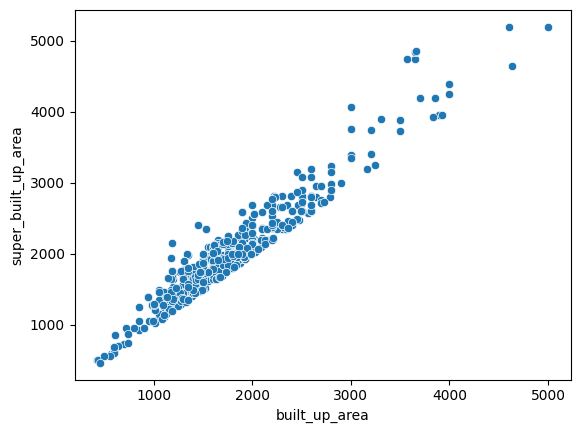

In [6]:
sns.scatterplot(x=df['built_up_area'],y=df['super_built_up_area'])

<Axes: xlabel='built_up_area', ylabel='carpet_area'>

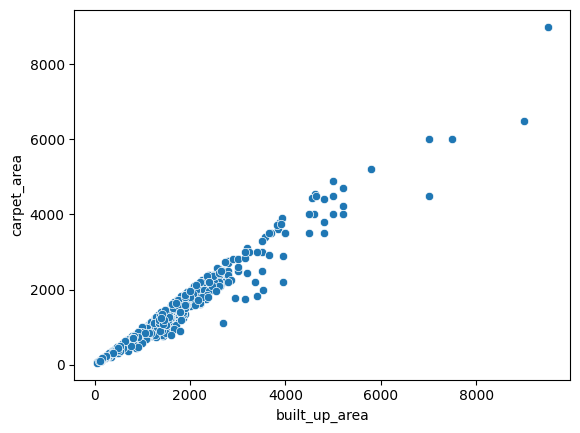

In [7]:
sns.scatterplot(x=df['built_up_area'],y=df['carpet_area'])

In [8]:
all_present_df=df[~((df['super_built_up_area'].isnull()) | (df['carpet_area'].isnull()) | (df['built_up_area'].isnull()))]

In [9]:
all_present_df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,age_category,furnishing_type,luxury_score,combined_rating,area_room_ratio
37,flat,ild greens,sector 37,0.78,5714.0,1365.0,Super Built up area 1365(126.81 sq.m.)Built Up...,2,2,3,1.0,North,1365.0,1068.1,900.0,0,0,0,0,0,Moderately Old,Furnished,58,4.70,682.500000
99,flat,emaar palm premier,sector 77,2.10,10500.0,2000.0,Super Built up area 2000(185.81 sq.m.)Built Up...,3,4,3+,11.0,NaN,2000.0,1600.0,1500.0,0,1,0,0,0,New Property,Furnished,72,4.25,666.666667
129,flat,umang monsoon breeze,sector 78,0.90,4615.0,1950.0,Super Built up area 1950(181.16 sq.m.)Built Up...,3,3,2,1.0,NaN,1950.0,1900.0,1854.0,0,1,0,1,0,Moderately Old,Unfurnished,44,4.25,650.000000
132,flat,supertech araville,sector 79,0.90,5882.0,1530.0,Super Built up area 1530(142.14 sq.m.)Built Up...,2,2,3,5.0,NaN,1530.0,1450.0,1400.0,1,0,0,0,0,Relatively New,Unfurnished,37,3.75,765.000000
137,flat,bhagwati sadan,sector 12,1.15,5750.0,2000.0,Super Built up area 2500(232.26 sq.m.)Built Up...,3,4,2,2.0,NaN,2500.0,2000.0,1750.0,1,1,0,0,1,Old Property,Furnished,12,3.88,666.666667


In [10]:
all_present_df.shape

(531, 25)

In [11]:
super_to_built_up_area_ratio=(all_present_df['super_built_up_area']/all_present_df['built_up_area']).median()
super_to_built_up_area_ratio

np.float64(1.105263157894737)

In [12]:
carpet_to_built_up_area_ratio=(all_present_df['carpet_area']/all_present_df['built_up_area']).median()
carpet_to_built_up_area_ratio

np.float64(0.9)

In [13]:
scb_df=df[~(df['super_built_up_area'].isnull()) & (df['built_up_area'].isnull()) & ~(df['carpet_area'].isnull())]

In [14]:
scb_df.shape

(421, 25)

In [15]:
scb_df['built_up_area']=scb_df['built_up_area'].fillna(round(((scb_df['super_built_up_area']/1.105)+(scb_df['carpet_area']/0.9))/2),inplace=True)

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_17060\4188751351.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  scb_df['built_up_area']=scb_df['built_up_area'].fillna(round(((scb_df['super_built_up_area']/1.105)+(scb_df['carpet_area']/0.9))/2),inplace=True)


In [16]:
df.update(scb_df)

In [17]:
df.isnull().sum()

property_type             0
society                   1
sector                    0
price                     0
price_per_sqft            0
area                      0
areaWithType              0
bedRoom                   0
bathroom                  0
balcony                   0
floorNum                 17
facing                 1014
super_built_up_area    1698
built_up_area          2033
carpet_area            1730
study room                0
servant room              0
store room                0
pooja room                0
others                    0
age_category              0
furnishing_type           0
luxury_score              0
combined_rating         333
area_room_ratio           0
dtype: int64

In [18]:
sb_df = df[~(df['super_built_up_area'].isnull()) & (df['built_up_area'].isnull()) & (df['carpet_area'].isnull())]

In [19]:
sb_df.sample(5)

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,age_category,furnishing_type,luxury_score,combined_rating,area_room_ratio
873,flat,dlf regal gardens,sector 90,1.25,7167.0,1744.0,Super Built up area 1744(162.02 sq.m.),3,3,2,11.0,East,1744.0,NaN,NaN,0,0,0,0,1,Relatively New,Unfurnished,6,4.50,581.333333
1877,flat,ireo uptown,sector 66,1.32,11438.0,1154.0,Super Built up area 1158(107.58 sq.m.),2,2,2,6.0,NaN,1158.0,NaN,NaN,0,0,0,0,0,Relatively New,Unfurnished,39,5.00,577.000000
167,flat,krrish florence estate,sector 70,1.25,6702.0,1865.0,Super Built up area 1865(173.26 sq.m.),3,3,3,18.0,North-East,1865.0,NaN,NaN,0,0,0,0,0,Under Construction,Unfurnished,38,3.62,621.666667
2751,flat,raheja vedaanta,sector 108,1.25,5682.0,2200.0,Super Built up area 2200(204.39 sq.m.),3,2,0,0.0,NaN,2200.0,NaN,NaN,0,0,0,0,0,Relatively New,Furnished,49,3.80,733.333333
361,flat,bptp terra,sector 37,2.08,10000.0,2080.0,Super Built up area 2443(226.96 sq.m.),4,4,3,0.0,North-East,2443.0,NaN,NaN,1,1,0,1,0,New Property,Unfurnished,75,4.40,520.000000


In [20]:
sb_df['built_up_area']=sb_df['built_up_area'].fillna(round(sb_df['super_built_up_area']/1.105),inplace=True)

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_17060\506460479.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  sb_df['built_up_area']=sb_df['built_up_area'].fillna(round(sb_df['super_built_up_area']/1.105),inplace=True)


In [21]:
df.update(sb_df)

In [22]:
df.isnull().sum()

property_type             0
society                   1
sector                    0
price                     0
price_per_sqft            0
area                      0
areaWithType              0
bedRoom                   0
bathroom                  0
balcony                   0
floorNum                 17
facing                 1014
super_built_up_area    1698
built_up_area          1157
carpet_area            1730
study room                0
servant room              0
store room                0
pooja room                0
others                    0
age_category              0
furnishing_type           0
luxury_score              0
combined_rating         333
area_room_ratio           0
dtype: int64

In [23]:
cb_df = df[(df['super_built_up_area'].isnull()) & (df['built_up_area'].isnull()) & ~(df['carpet_area'].isnull())]

In [24]:
cb_df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,age_category,furnishing_type,luxury_score,combined_rating,area_room_ratio
0,flat,maa bhagwati residency,sector 7,0.45,5000.0,900.0,Carpet area: 900 (83.61 sq.m.),2,2,1,4.0,West,NaN,NaN,900.0,0,0,0,0,0,Relatively New,Unfurnished,11,4.00,450.000000
1,flat,apna enclave,sector 3,0.50,7692.0,650.0,Carpet area: 650 (60.39 sq.m.),2,2,1,1.0,West,NaN,NaN,650.0,0,0,0,0,0,Old Property,Furnished,14,4.25,325.000000
2,flat,tulsiani easy in homes,sohna road,0.40,6723.0,595.0,Carpet area: 595 (55.28 sq.m.),2,2,3,12.0,NaN,NaN,NaN,595.0,0,0,0,0,0,New Property,Unfurnished,31,4.25,297.500000
3,flat,smart world orchard,sector 61,1.47,12250.0,1200.0,Carpet area: 1200 (111.48 sq.m.),2,2,2,2.0,NaN,NaN,NaN,1200.0,1,0,0,0,0,Relatively New,Unfurnished,49,NaN,600.000000
7,flat,ats triumph,sector 104,1.80,7860.0,2290.0,Carpet area: 2290 (212.75 sq.m.),3,4,3,14.0,NaN,NaN,NaN,2290.0,0,0,0,0,0,New Property,Unfurnished,44,4.70,763.333333


In [25]:
cb_df['built_up_area']=cb_df['built_up_area'].fillna(round(df['carpet_area']/0.9),inplace=True)

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_17060\3217889430.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  cb_df['built_up_area']=cb_df['built_up_area'].fillna(round(df['carpet_area']/0.9),inplace=True)


In [26]:
df.update(cb_df)

In [27]:
df.isnull().sum()

property_type             0
society                   1
sector                    0
price                     0
price_per_sqft            0
area                      0
areaWithType              0
bedRoom                   0
bathroom                  0
balcony                   0
floorNum                 17
facing                 1014
super_built_up_area    1698
built_up_area           485
carpet_area            1730
study room                0
servant room              0
store room                0
pooja room                0
others                    0
age_category              0
furnishing_type           0
luxury_score              0
combined_rating         333
area_room_ratio           0
dtype: int64

In [28]:
df['built_up_area']=df['built_up_area'].fillna(df['area'])

In [29]:
df.isnull().sum()

property_type             0
society                   1
sector                    0
price                     0
price_per_sqft            0
area                      0
areaWithType              0
bedRoom                   0
bathroom                  0
balcony                   0
floorNum                 17
facing                 1014
super_built_up_area    1698
built_up_area             0
carpet_area            1730
study room                0
servant room              0
store room                0
pooja room                0
others                    0
age_category              0
furnishing_type           0
luxury_score              0
combined_rating         333
area_room_ratio           0
dtype: int64

<Axes: xlabel='built_up_area', ylabel='price'>

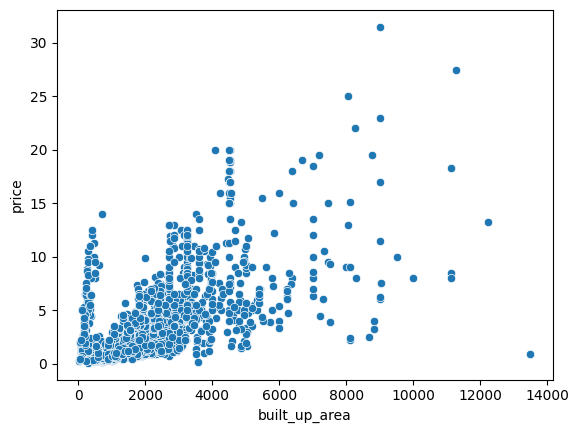

In [30]:
sns.scatterplot(x=df['built_up_area'],y=df['price'])

In [31]:
df.isnull().sum()

property_type             0
society                   1
sector                    0
price                     0
price_per_sqft            0
area                      0
areaWithType              0
bedRoom                   0
bathroom                  0
balcony                   0
floorNum                 17
facing                 1014
super_built_up_area    1698
built_up_area             0
carpet_area            1730
study room                0
servant room              0
store room                0
pooja room                0
others                    0
age_category              0
furnishing_type           0
luxury_score              0
combined_rating         333
area_room_ratio           0
dtype: int64

In [32]:
df.drop(columns=['super_built_up_area','carpet_area'],inplace=True)

In [33]:
df.isnull().sum()

property_type         0
society               1
sector                0
price                 0
price_per_sqft        0
area                  0
areaWithType          0
bedRoom               0
bathroom              0
balcony               0
floorNum             17
facing             1014
built_up_area         0
study room            0
servant room          0
store room            0
pooja room            0
others                0
age_category          0
furnishing_type       0
luxury_score          0
combined_rating     333
area_room_ratio       0
dtype: int64

In [34]:
df.head(1)

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,built_up_area,study room,servant room,store room,pooja room,others,age_category,furnishing_type,luxury_score,combined_rating,area_room_ratio
0,flat,maa bhagwati residency,sector 7,0.45,5000.0,900.0,Carpet area: 900 (83.61 sq.m.),2,2,1,4.0,West,1000.0,0,0,0,0,0,Relatively New,Unfurnished,11,4.0,450.0


In [35]:
anamoly_df=df[(df['built_up_area']<1000) & (df['price']>2.5)][['property_type','society','price','price_per_sqft','area','areaWithType','built_up_area']]

In [36]:
anamoly_df['built_up_area']=anamoly_df['built_up_area']*10.764

In [37]:
anamoly_df.sample(5)

,property_type,society,price,price_per_sqft,area,areaWithType,built_up_area
3525,house,independent,6.46,18889.0,3420.0,Plot area 380(317.73 sq.m.)Built Up area: 380 ...,4090.320
2865,house,emaar mgf marbella,8.80,41608.0,2115.0,Built Up area: 267 (223.25 sq.m.),2873.988
3509,house,unitech espace,7.50,34722.0,2160.0,Plot area 240(200.67 sq.m.)Built Up area: 241 ...,2594.124
3126,house,unitech escape,12.00,37037.0,3240.0,Carpet area: 360 (301.01 sq.m.),4305.600
2981,house,independent,3.50,24306.0,1440.0,Carpet area: 160 (133.78 sq.m.),1915.992


In [38]:
df.update(anamoly_df)

<Axes: xlabel='built_up_area', ylabel='price'>

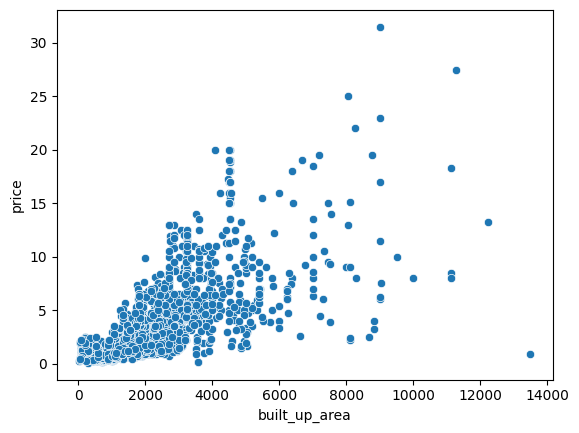

In [39]:
sns.scatterplot(x=df['built_up_area'],y=df['price'])

In [40]:
df.drop(columns=['area','area_room_ratio'],inplace=True)

In [41]:
df.isnull().sum()

property_type         0
society               1
sector                0
price                 0
price_per_sqft        0
areaWithType          0
bedRoom               0
bathroom              0
balcony               0
floorNum             17
facing             1014
built_up_area         0
study room            0
servant room          0
store room            0
pooja room            0
others                0
age_category          0
furnishing_type       0
luxury_score          0
combined_rating     333
dtype: int64

FLOORNUM

In [42]:
df[df['floorNum'].isnull()]

,property_type,society,sector,price,price_per_sqft,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,built_up_area,study room,servant room,store room,pooja room,others,age_category,furnishing_type,luxury_score,combined_rating
169,flat,experion heartsong,dwarka expressway,1.08,6150.0,Built Up area: 1758 (163.32 sq.m.),3,3,0,NaN,NaN,1758.0,0,0,0,0,0,Under Construction,Unfurnished,0,NaN
2577,flat,NaN,sector 78,0.60,3692.0,Built Up area: 1625 (150.97 sq.m.),2,2,0,NaN,NaN,1625.0,0,0,0,0,0,Under Construction,Unfurnished,0,4.25
2827,house,vipul tatvam villa,sector 48,8.50,26235.0,Plot area 360(301.01 sq.m.),4,4,2,NaN,East,3240.0,0,1,1,1,0,Moderately Old,Unfurnished,62,4.25
2849,house,independent,sector 2,5.60,17284.0,Plot area 360(301.01 sq.m.),8,6,3+,NaN,South-West,3240.0,1,1,1,1,0,Moderately Old,Unfurnished,0,4.75
2922,house,independent,sector 24,1.45,2984.0,Plot area 60(50.17 sq.m.),3,3,1,NaN,NaN,4860.0,0,0,0,0,0,Old Property,Unfurnished,10,4.50
2953,house,independent,sector 3,1.50,10288.0,Plot area 162(135.45 sq.m.)Built Up area: 210 ...,3,3,0,NaN,NaN,210.0,0,0,0,0,0,Old Property,Unfurnished,0,4.25
2966,house,independent,sector 4,4.12,8889.0,Plot area 515(430.61 sq.m.),2,1,3+,NaN,NaN,4635.0,0,0,0,0,0,Moderately Old,Unfurnished,0,NaN
3012,house,independent,sector 4,0.65,11111.0,Plot area 65(54.35 sq.m.),4,2,2,NaN,NaN,585.0,0,0,0,0,0,Moderately Old,Unfurnished,0,4.25
3027,house,ansal sushant lok plots,sector 43,3.30,26570.0,Plot area 138(115.39 sq.m.),1,1,0,NaN,NaN,1242.0,0,0,0,0,0,Under Construction,Unfurnished,0,5.00
3147,house,jacob pura,sector 12,0.35,9722.0,Built Up area: 360 (33.45 sq.m.),2,1,0,NaN,NaN,360.0,0,0,0,0,0,Old Property,Unfurnished,0,4.00


In [43]:
df[df['property_type']=='house']['floorNum'].median()

np.float64(2.0)

In [44]:
df['floorNum']=df['floorNum'].fillna(2)

In [45]:
df.isnull().sum()

property_type         0
society               1
sector                0
price                 0
price_per_sqft        0
areaWithType          0
bedRoom               0
bathroom              0
balcony               0
floorNum              0
facing             1014
built_up_area         0
study room            0
servant room          0
store room            0
pooja room            0
others                0
age_category          0
furnishing_type       0
luxury_score          0
combined_rating     333
dtype: int64

In [46]:
df.head(2)

,property_type,society,sector,price,price_per_sqft,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,built_up_area,study room,servant room,store room,pooja room,others,age_category,furnishing_type,luxury_score,combined_rating
0,flat,maa bhagwati residency,sector 7,0.45,5000.0,Carpet area: 900 (83.61 sq.m.),2,2,1,4.0,West,1000.0,0,0,0,0,0,Relatively New,Unfurnished,11,4.00
1,flat,apna enclave,sector 3,0.50,7692.0,Carpet area: 650 (60.39 sq.m.),2,2,1,1.0,West,722.0,0,0,0,0,0,Old Property,Furnished,14,4.25


In [47]:
# Society fill
df['facing'] = df.groupby('society')['facing'].transform(
    lambda x: x.fillna(x.mode().iloc[0] if not x.mode().empty else np.nan)
)

# Sector fallback
df['facing'] = df.groupby('sector')['facing'].transform(
    lambda x: x.fillna(x.mode().iloc[0] if not x.mode().empty else np.nan)
)

In [48]:
df.isnull().sum()

property_type        0
society              1
sector               0
price                0
price_per_sqft       0
areaWithType         0
bedRoom              0
bathroom             0
balcony              0
floorNum             0
facing               0
built_up_area        0
study room           0
servant room         0
store room           0
pooja room           0
others               0
age_category         0
furnishing_type      0
luxury_score         0
combined_rating    333
dtype: int64

In [49]:
df[df['society'].isnull()]

,property_type,society,sector,price,price_per_sqft,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,built_up_area,study room,servant room,store room,pooja room,others,age_category,furnishing_type,luxury_score,combined_rating
2577,flat,NaN,sector 78,0.6,3692.0,Built Up area: 1625 (150.97 sq.m.),2,2,0,2.0,East,1625.0,0,0,0,0,0,Under Construction,Unfurnished,0,4.25


In [50]:
df.drop(index=2577,inplace=True)

In [51]:
df.isnull().sum()

property_type        0
society              0
sector               0
price                0
price_per_sqft       0
areaWithType         0
bedRoom              0
bathroom             0
balcony              0
floorNum             0
facing               0
built_up_area        0
study room           0
servant room         0
store room           0
pooja room           0
others               0
age_category         0
furnishing_type      0
luxury_score         0
combined_rating    333
dtype: int64

AGE_CATEGORY

In [52]:
df['age_category'].value_counts()

age_category
Relatively New        1755
New Property           587
Moderately Old         545
Old Property           294
Undefined              294
Under Construction      98
Name: count, dtype: int64

In [53]:
def fill_age_category(df):
    # Step 1: sector + property_type
    def fill_group(group):
        mode = group[group != 'Undefined'].mode()
        return group.replace('Undefined', mode.iloc[0]) if not mode.empty else group

    df['age_category'] = (
        df.groupby(['sector', 'property_type'])['age_category']
          .transform(fill_group)
    )

    # Step 2: sector fallback
    df['age_category'] = (
        df.groupby('sector')['age_category']
          .transform(fill_group)
    )

    return df

In [54]:
df = fill_age_category(df)

In [55]:
df['age_category'].value_counts()

age_category
Relatively New        1902
New Property           630
Moderately Old         613
Old Property           330
Under Construction      98
Name: count, dtype: int64

In [56]:
df.isnull().sum()

property_type        0
society              0
sector               0
price                0
price_per_sqft       0
areaWithType         0
bedRoom              0
bathroom             0
balcony              0
floorNum             0
facing               0
built_up_area        0
study room           0
servant room         0
store room           0
pooja room           0
others               0
age_category         0
furnishing_type      0
luxury_score         0
combined_rating    333
dtype: int64

In [57]:
def fill_combined_rating(df):
    # Society median
    df['combined_rating'] = df.groupby('society')['combined_rating'].transform(
        lambda x: x.fillna(x.median())
    )

    # Sector median fallback
    df['combined_rating'] = df.groupby('sector')['combined_rating'].transform(
        lambda x: x.fillna(x.median())
    )

    # Overall median fallback
    df['combined_rating'] = df['combined_rating'].fillna(
        df['combined_rating'].median()
    )

    return df

In [58]:
df = fill_combined_rating(df)

In [59]:
df.isnull().sum()

property_type      0
society            0
sector             0
price              0
price_per_sqft     0
areaWithType       0
bedRoom            0
bathroom           0
balcony            0
floorNum           0
facing             0
built_up_area      0
study room         0
servant room       0
store room         0
pooja room         0
others             0
age_category       0
furnishing_type    0
luxury_score       0
combined_rating    0
dtype: int64

In [60]:
df.shape

(3573, 21)

In [61]:
df.to_csv('gurgaon_properties_missing_value_imputation.csv',index=False)